Validation RMSE: 10.9629
Validation MAE: 6.8362
Validation R^2: 0.7420
Cross-validation RMSE: 10.8946 ± 0.0537
Submission file created: submission3.csv


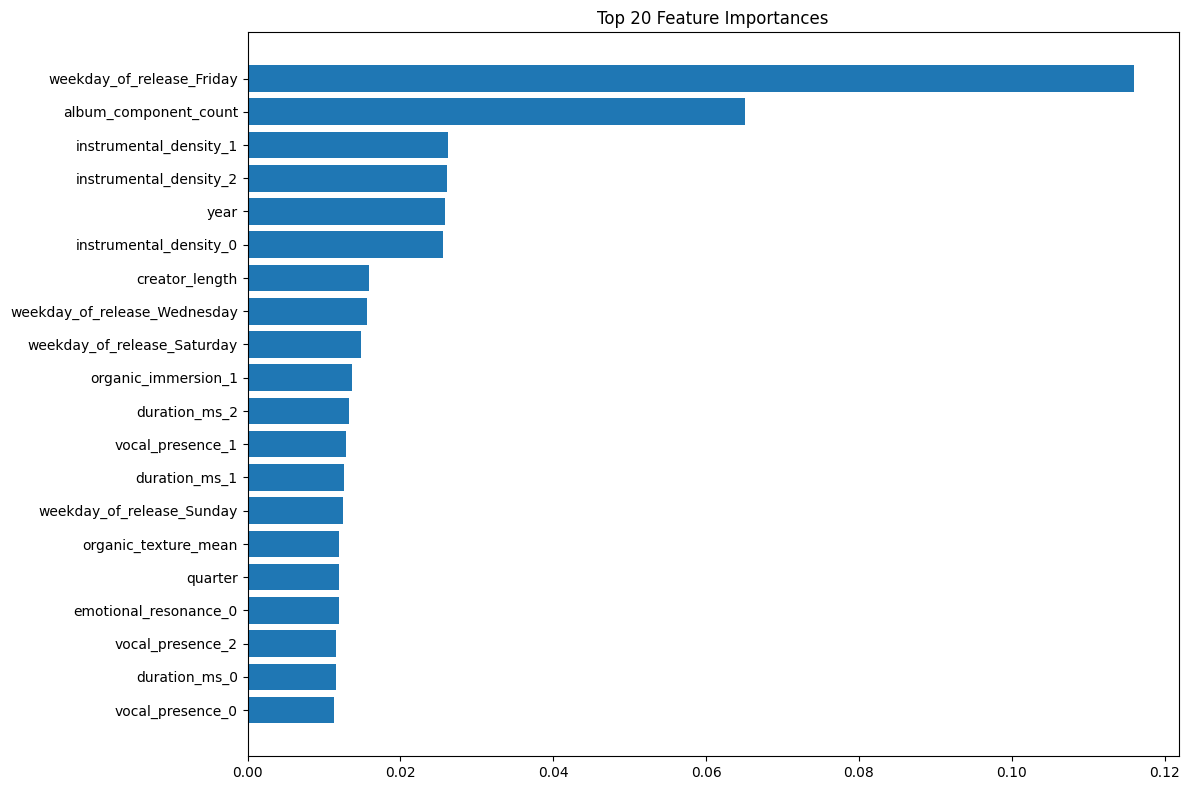

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Extract target variable from training data
X_full = train_data.drop(['target'], axis=1)
y_full = train_data['target']

# Function to preprocess data
def preprocess_data(df):
    # Make a copy to avoid modifying the original dataframe
    data = df.copy()
    
    # Extract datetime features from publication_timestamp
    data['publication_timestamp'] = pd.to_datetime(data['publication_timestamp'])
    data['year'] = data['publication_timestamp'].dt.year
    data['month'] = data['publication_timestamp'].dt.month
    data['day'] = data['publication_timestamp'].dt.day
    data['day_of_year'] = data['publication_timestamp'].dt.dayofyear
    data['quarter'] = data['publication_timestamp'].dt.quarter
    
    # Create artist name length
    data['creator_length'] = data['creator_collective'].apply(lambda x: len(str(x)))
    
    # Process track_identifier (title) features
    data['track_identifier_length'] = data['track_identifier'].apply(lambda x: len(str(x)))
    data['track_identifier_word_count'] = data['track_identifier'].apply(lambda x: len(str(x).split()))
    
    # Calculate additional statistics for audio features across tracks
    audio_features = ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'beat_frequency']
    
    for feature in audio_features:
        # Get all columns related to this feature across tracks
        cols = [col for col in data.columns if feature in col]
        
        if len(cols) > 1:
            # Calculate mean across tracks
            data[f'{feature}_mean'] = data[cols].mean(axis=1)
            # Calculate standard deviation across tracks
            data[f'{feature}_std'] = data[cols].std(axis=1)
            # Calculate range across tracks
            data[f'{feature}_range'] = data[cols].max(axis=1) - data[cols].min(axis=1)
    
    # Calculate audio feature ratios and interactions
    # Energy to danceability ratio for all tracks
    for i in range(3):  # For tracks 0-2
        data[f'energy_dance_ratio_{i}'] = data[f'intensity_index_{i}'] / (data[f'rhythmic_cohesion_{i}'] + 0.001)
        data[f'dance_energy_product_{i}'] = data[f'intensity_index_{i}'] * data[f'rhythmic_cohesion_{i}']
    
    # Drop columns that shouldn't be used for modeling
    drop_columns = ['track_identifier', 'creator_collective', 'publication_timestamp', 
                   'composition_label_0', 'composition_label_1', 'composition_label_2']
    
    # Check if columns exist before dropping
    drop_columns = [col for col in drop_columns if col in data.columns]
    data = data.drop(drop_columns, axis=1)
    
    return data

# Preprocess data
X_processed = preprocess_data(X_full)
test_processed = preprocess_data(test_data)

# Split data for training and validation
X_train, X_val, y_train, y_val = train_test_split(X_processed, y_full, test_size=0.2, random_state=42)

# Identify numeric and categorical columns
numeric_features = X_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_processed.select_dtypes(include=['object']).columns.tolist()

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define the XGBoost model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Create the full pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Evaluate on validation set
y_pred = model_pipeline.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")

# Perform cross-validation
cv_scores = cross_val_score(model_pipeline, X_processed, y_full, 
                           cv=5, scoring='neg_root_mean_squared_error')
print(f"Cross-validation RMSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

# Comment out for faster execution or use a smaller param_grid
# grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, 
#                           scoring='neg_root_mean_squared_error', n_jobs=-1)
# grid_search.fit(X_processed, y_full)
# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best cross-validation RMSE: {-grid_search.best_score_:.4f}")

# Feature importance analysis
# Get feature names after preprocessing
preprocessor.fit(X_processed)
feature_names = numeric_features.copy()

# Add one-hot encoded feature names
if categorical_features:
    ohe_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
    feature_names.extend(ohe_feature_names)

# Train the model directly on preprocessed data to get feature importance
preprocessed_train = preprocessor.transform(X_processed)
final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(preprocessed_train, y_full)

# Plot feature importance
plt.figure(figsize=(12, 8))
sorted_idx = np.argsort(final_model.feature_importances_)[-20:]  # Top 20 features
plt.barh(range(len(sorted_idx)), final_model.feature_importances_[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png')

# Make predictions on test set
test_predictions = model_pipeline.predict(test_processed)

# Prepare submission file
submission = pd.DataFrame({
    'id': test_data['id'] if 'id' in test_data.columns else range(len(test_data)),
    'target': test_predictions
})

# Ensure predictions are within the valid range (0-100)
submission['target'] = submission['target'].clip(0, 100)

# Save submission file
submission.to_csv('submission3.csv', index=False)
print("Submission file created: submission3.csv")